# Natural Language Processing: Words, Tokens, and Regular Expressions
## Exercises Notebook - Session 3

This notebook contains exercises covering:
- Tokenization concepts

---
## Section 1: Tokenization Concepts
---

### Exercise 1.1: Types vs Instances

The slides distinguish between types and instances.
For the given text, calculate:
1. Number of instances (total tokens)
2. Number of types (vocabulary size |V|)
3. Type-token ratio

In [103]:
# YOUR CODE HERE
text = "the cat sat on the mat the cat was fat"
tokens = text.split()
# The first part is checking the length of the tokens list or which is the same the number of instances thats how you count all the words. 
# The second part turns the list of words into a set removing the duplicates to count how many different words appear or the number of types. 
# The last part divides the number of types by the number of instances to calculate the Type-Token Ratio, which tells you how diverse the vocabulary is in the text.
instances = len(tokens)
types = len(set(tokens))
ttr = types / instances

print(f"Instancias: {instances}")
print(f"Tipos (Vocabulario): {types}")
print(f"Type-Token Ratio: {ttr:.2f}")

Instancias: 10
Tipos (Vocabulario): 7
Type-Token Ratio: 0.70


### Exercise 1.2: Heaps' Law Demonstration

The slides mention Heaps' Law: vocabulary size grows with √N.

Generate text of increasing length and observe vocabulary growth.

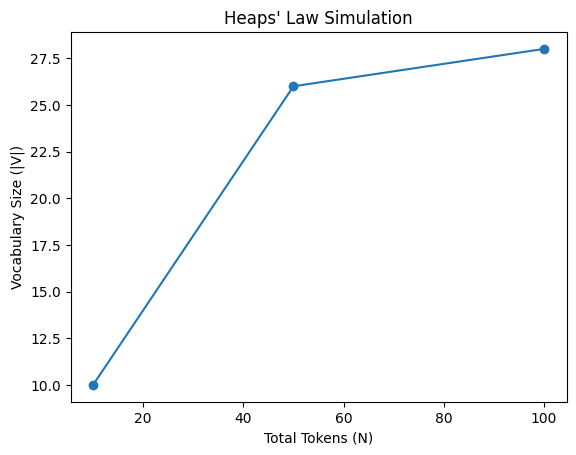

In [104]:
# YOUR CODE HERE
import random
import matplotlib.pyplot as plt
# Use a simple word list to simulate text
word_list = ['the', 'a', 'is', 'are', 'was', 'were', 'be', 'been',
             'cat', 'dog', 'bird', 'fish', 'tree', 'house', 'car',
             'run', 'walk', 'jump', 'eat', 'sleep', 'read', 'write',
             'big', 'small', 'fast', 'slow', 'red', 'blue', 'green']
# First of all you choose different text lengths in N_values, like 10 words, 50 words,100 words or even higher. 
# For each length, randomly generate a text by picking words from the list and counts how many unique words appear in that text.
# Those vocabulary sizes are stored and then plotted using matplotlib. 
# Shows in a graph how the total number of words increases, but the number of unique words increases slowly because new words become harder to find if so many others have already been used.
N_values = [10, 50, 100]
vocab_sizes = []

for N in N_values:
    simulated_text = [random.choice(word_list) for _ in range(N)]
    vocab_sizes.append(len(set(simulated_text)))

plt.plot(N_values, vocab_sizes, marker='o')
plt.title("Heaps' Law Simulation")
plt.xlabel("Total Tokens (N)")
plt.ylabel("Vocabulary Size (|V|)")
plt.show()

### Exercise 1.3: BPE Simulation

The slides explain Byte Pair Encoding (BPE).
Implement a simple BPE token learner that:
1. Starts with character vocabulary
2. Finds most frequent adjacent pair
3. Merges them into a new token
4. Repeats k times

In [105]:
from collections import Counter

def simple_bpe(corpus, num_merges):
    # 1. Inicialización: dividimos palabras en caracteres individuales
    # 'low' -> ['l', 'o', 'w', '</w>']
    words = [list(word) + ['</w>'] for word in corpus.split()]
    
    for i in range(num_merges):
        # 2. Encontrar todos los pares de tokens adyacentes
        pairs = Counter()
        for word in words:
            for j in range(len(word) - 1):
                pairs[word[j], word[j+1]] += 1
        
        if not pairs:
            break
            
        # 3. Elegir el par más frecuente
        best_pair = pairs.most_common(1)[0][0]
        
        # 4. Fusionar el par en todas las palabras
        new_words = []
        for word in words:
            new_word = []
            j = 0
            while j < len(word):
                # Si encontramos el par, lo unimos
                if j < len(word) - 1 and (word[j], word[j+1]) == best_pair:
                    new_word.append(best_pair[0] + best_pair[1])
                    j += 2
                else:
                    new_word.append(word[j])
                    j += 1
            new_words.append(new_word)
        words = new_words
        print(f"Merge {i+1}: {best_pair} -> Vocabulario: {' '.join(set(sum(words, [])))}")
        
    return words

corpus = "low lower newest widest"
result = simple_bpe(corpus, 5)

Merge 1: ('l', 'o') -> Vocabulario: t </w> i d r e s lo n w
Merge 2: ('lo', 'w') -> Vocabulario: t </w> i d r e s low n w
Merge 3: ('e', 's') -> Vocabulario: t </w> i d r e es low n w
Merge 4: ('es', 't') -> Vocabulario: </w> i d r est e low n w
Merge 5: ('est', '</w>') -> Vocabulario: </w> i est</w> d r e low n w


---
## Section 2: Advanced Regex
---

### Exercise 2.1: Lookahead Assertions

The slides introduce lookahead: (?=pattern) and (?!pattern)

Write patterns to:
1. Find words followed by a comma (without capturing comma)
2. Find first word of line only if it doesn't start with 'T'

In [106]:
# YOUR CODE HERE
import re
text = "The quick, brown fox jumps over the lazy dog."
words_before_comma = re.findall(r'\w+(?=,)', text)
first_word_not_T = re.findall(r'^(?!T)(\w+)', text)

### Exercise 2.2: Non-capturing Groups

The slides explain (?:...) for grouping without capturing.

Write a pattern that matches "some cats" or "a few cats" 
but only captures "cats" (not "some" or "a few").

In [107]:
# YOUR CODE HERE
texts = [
    "some cats like fish",
    "a few cats play outside", 
    "some dogs bark"
]

### Exercise 2.3: GPT-2 Pre-tokenization

The slides show the GPT-2 pre-tokenization regex.
Test the pattern and understand what each part does.

In [108]:
# YOUR CODE HERE
gpt2_pattern = r"'s|'t|'re|'ve|'m|'ll|'d|\w+|\d+|[^\s\w]+"
test = "I'm learning NLP! It's fascinating. I've got 100 examples."

---
## Section 3: Morphology
---

### Exercise 3.1: Identifying Morphemes

The slides define morphemes as minimal meaning-bearing units.

Write code to identify potential morphemes by finding:
1. Common suffixes (-ed, -ing, -s, -ly, -ful)
2. Common prefixes (un-, re-, pre-, dis-)

In [109]:
# YOUR CODE HERE
words = ["working", "unhappy", "carefully", "reworked", "glasses", "preprocessing"]